# Saving graphs for neural-lam

From the first tagged version of [neural-lam](https://github.com/mllam/neural-lam) ([v0.1.0](https://github.com/mllam/neural-lam/tree/v0.1.0) and currently (as of `v0.4.0`)) has a very specific format that the saved graphs are expected to be in based on pickled pytorch tensors. This notebook describes how to save graphs in that format and what the format is.

In [1]:
import weather_model_graphs as wmg
import numpy as np
import matplotlib.pyplot as plt
import torch
import networkx as nx

In [2]:
def create_fake_irregular_coords(num_grid_points=100):
    """
    Create fake grid points on random coordinates
    """
    rng = np.random.default_rng(seed=42)  # Fixed seed
    # All coordinates in [0,1]^2
    return rng.random((num_grid_points, 2))

((0.0, 1.0), (0.0, 1.0))

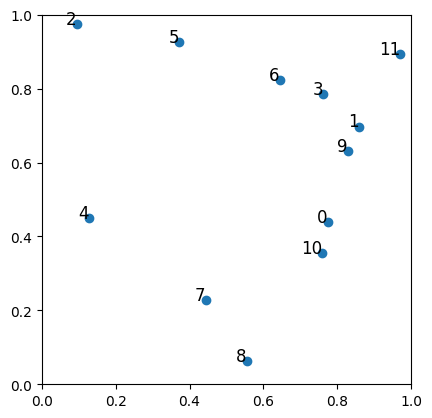

In [3]:
coords = create_fake_irregular_coords(num_grid_points=12)

fig, ax = plt.subplots()
ax.scatter(coords[:, 0], coords[:, 1])
# add labels
for i, (x, y) in enumerate(coords):
    ax.text(x, y, str(i), fontsize=12, ha="right")
ax.set_aspect("equal")
ax.set_xlim(0, 1), ax.set_ylim(0, 1)

2025-10-28 13:37:01.418 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:94 - No `coords_crs` given: Assuming `coords` contains in-projection Cartesian coordinates.


<Axes: >

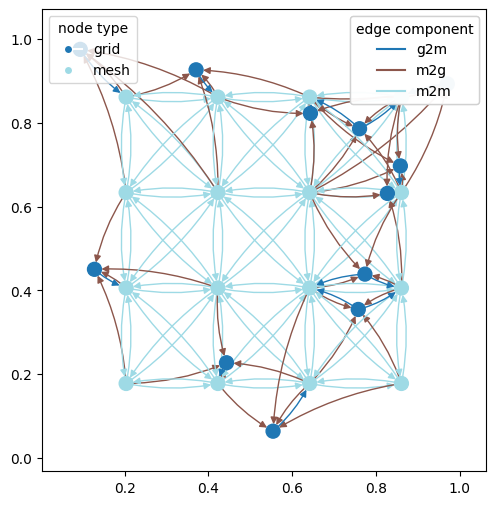

In [4]:
graph = wmg.create.archetype.create_keisler_graph(coords=coords, mesh_node_distance=0.2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
wmg.visualise.nx_draw_with_pos_and_attr(
    graph=graph, ax=ax, node_color_attr="type", edge_color_attr="component"
)

`neural-lam` expects the _subgraphs_ that are individually used for subsequent message passing operations to be saved separately. For the Keisler graph, this means that we need to split the graph into subgraphs that do the mesh-to-grid (`m2g`), mesh-to-mesh (`m2m`), grid-to-mesh (`g2m`), and grid-to-grid (`g2g`) operations. In `weather-model-graphs` edges have a `component` attribute that indicates which of these operations they belong to, so we can use this to split the graph.

In [5]:
subgraphs = wmg.split_graph_by_edge_attribute(graph=graph, attr="component")
subgraphs

{'m2m': <networkx.classes.digraph.DiGraph at 0x126f3c5c0>,
 'g2m': <networkx.classes.digraph.DiGraph at 0x126fd3b00>,
 'm2g': <networkx.classes.digraph.DiGraph at 0x126fd2060>}

In [6]:
outputdir = "keisler_graph_for_neural_lam"
for subgraph_name, subgraph_dict in subgraphs.items():
    wmg.save.to_pyg(subgraph_dict, output_directory=outputdir, name=subgraph_name)

! tree {outputdir}

/Users/B280936/git-repos/mllam/weather-model-graphs/.venv/lib/python3.12/site-packages/torch_geometric/utils/convert.py:278: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:277.)
  data_dict[key] = torch.as_tensor(value)
2025-10-28 13:37:01.669 | INFO     | weather_model_graphs.save:to_pyg:139 - Saved edge index to keisler_graph_for_neural_lam/m2m_edge_index.pt and features ['len', 'vdiff'] to keisler_graph_for_neural_lam/m2m_features.pt.
2025-10-28 13:37:01.669 | INFO     | weather_model_graphs.save:to_pyg:146 - Saved node features ['pos'] to keisler_graph_for_neural_lam/m2m_node_features.pt.
2025-10-28 13:37:01.671 | INFO     | weather_model_graphs.save:to_pyg:139 - Saved edge index to keisler_graph_for_neural_lam/g2m_edge_index.pt and features

keisler_graph_for_neural_lam
├── g2m_edge_index.pt
├── g2m_features.pt
├── g2m_node_features.pt
├── m2g_edge_index.pt
├── m2g_features.pt
├── m2g_node_features.pt
├── m2m_edge_index.pt
├── m2m_features.pt
└── m2m_node_features.pt

1 directory, 9 files


In [7]:
def load_nl_subgraph_format(base_path, graph_name):
    adj_list = torch.load(f"{base_path}/{graph_name}_edge_index.pt")
    edge_features = torch.load(f"{base_path}/{graph_name}_features.pt")
    node_features = torch.load(f"{base_path}/{graph_name}_node_features.pt")
    return {
        "edge_adj_list": adj_list,
        "edge_features": edge_features,
        "node_features": node_features,
    }


nl_g2m_subgraph_dict = load_nl_subgraph_format("keisler_graph_for_neural_lam", "g2m")
nl_g2m_subgraph_dict

{'edge_adj_list': tensor([[10, 10, 11, 12, 13, 13, 14, 15, 16, 17, 18, 19, 20, 20, 21],
         [ 5,  7,  8,  1,  6,  9,  0,  3,  6,  2,  4,  8,  5,  7,  9]]),
 'edge_features': tensor([[ 0.1360,  0.1320,  0.0331],
         [ 0.0933, -0.0872,  0.0331],
         [ 0.0637, -0.0025,  0.0637],
         [ 0.1581, -0.1096,  0.1140],
         [ 0.1411,  0.1191, -0.0756],
         [ 0.1253, -0.1000, -0.0756],
         [ 0.0878, -0.0756,  0.0446],
         [ 0.0834, -0.0521,  0.0651],
         [ 0.0389,  0.0019, -0.0389],
         [ 0.0535,  0.0205,  0.0494],
         [ 0.1436, -0.0874, -0.1140],
         [ 0.0336, -0.0335, -0.0020],
         [ 0.1269,  0.1161, -0.0512],
         [ 0.1151, -0.1030, -0.0512],
         [ 0.1140,  0.1096,  0.0315]]),
 'node_features': [tensor([[0.2037, 0.4057],
          [0.2037, 0.8616],
          [0.4229, 0.1778],
          [0.4229, 0.8616],
          [0.6420, 0.1778],
          [0.6420, 0.4057],
          [0.6420, 0.8616],
          [0.8611, 0.4057],
         

Let's start by looking shapes of the edge adjacency list, edge features and node features for the three subgraphs:

In [8]:
def print_shapes_of_nl_subgraphs(basedir, graph_components=["g2m", "m2m", "m2g"]):
    for component in graph_components:
        subgraph_dict = load_nl_subgraph_format(basedir, component)
        print(f"Component: {component}")
        print(f"  Edge adjacency list shape:   {subgraph_dict['edge_adj_list'].shape}")
        print(f"  Edge features shape:         {subgraph_dict['edge_features'].shape}")
        print(
            f"  Node features shape:         {[nf.shape for nf in subgraph_dict['node_features']]}"
        )
        print()


print_shapes_of_nl_subgraphs("keisler_graph_for_neural_lam")

Component: g2m
  Edge adjacency list shape:   torch.Size([2, 15])
  Edge features shape:         torch.Size([15, 3])
  Node features shape:         [torch.Size([22, 2])]

Component: m2m
  Edge adjacency list shape:   torch.Size([2, 84])
  Edge features shape:         torch.Size([84, 3])
  Node features shape:         [torch.Size([16, 2])]

Component: m2g
  Edge adjacency list shape:   torch.Size([2, 48])
  Edge features shape:         torch.Size([48, 3])
  Node features shape:         [torch.Size([28, 2])]



Next we will will construct `networkx.DiGraph` objects for each of these subgraphs so we can visualise them and check that they look correct.

In [9]:
def graph_from_nl_subgraph_format(nl_subgraph_dict):
    g = nx.DiGraph()
    edge_adj_list = nl_subgraph_dict["edge_adj_list"].numpy()
    edge_features = nl_subgraph_dict["edge_features"].numpy()
    node_features = [nf.numpy() for nf in nl_subgraph_dict["node_features"]]

    n_edges = edge_adj_list.shape[1]
    assert (
        edge_features.shape[0] == n_edges
    ), "Number of edges in adjacency list and features do not match"
    n_nodes = node_features[0].shape[0]
    assert (
        len(np.unique(edge_adj_list)) == n_nodes
    ), "Number of unique nodes in adjacency list exceeds number of node features"

    # add nodes
    for i in range(n_nodes):
        nf = node_features[0][i]
        # assume node features are [pos[0], pos[1]]
        node_pos = (nf[0], nf[1])
        g.add_node(i, pos=node_pos)

    # Add edges
    for i in range(edge_adj_list.shape[1]):
        src = int(edge_adj_list[0, i])
        dst = int(edge_adj_list[1, i])
        # assume edges features are [len, vec[0], vec[1]]
        e_features = edge_features[i]
        edge_features_named = {
            "len": float(e_features[0]),
            "vec": (float(e_features[1]), float(e_features[2])),
        }
        g.add_edge(src, dst, **edge_features_named)

    return g


nl_g2m_subgraph = graph_from_nl_subgraph_format(nl_g2m_subgraph_dict)
nl_g2m_subgraph

<Axes: >

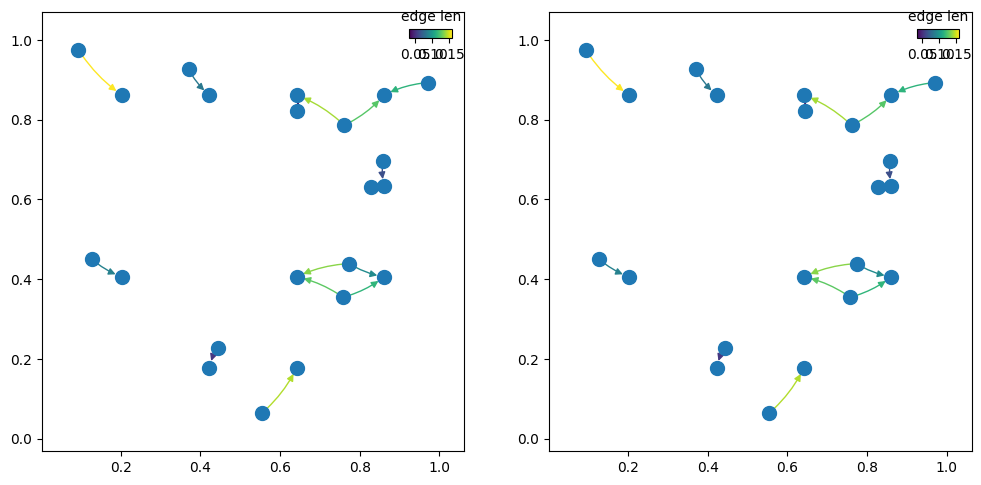

In [10]:
kwargs = dict(edge_color_attr="len")
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
[ax.set_aspect("equal") for ax in axes]
# original graph
ax = axes[0]
wmg.visualise.nx_draw_with_pos_and_attr(graph=subgraphs["g2m"], ax=ax, **kwargs)
# loaded graph
ax = axes[1]
wmg.visualise.nx_draw_with_pos_and_attr(graph=nl_g2m_subgraph, ax=ax, **kwargs)

## Assumptions in neural-lam pytorch subgraph disk format

TODO: Need to write about the indexing values and order of indexes in the adjacency list, edge features and node features.